In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import drive

# 1. Mount Google Drive to access files
drive.mount('/content/drive')

# 2. Load the dataset files using numpy
path = "/content/drive/MyDrive/NeuralNetworks_Assignment2/"
max_agg = np.loadtxt(path + "CoffeeMachinemaxAgg.txt", delimiter=',')
max_app = np.loadtxt(path + "CoffeeMachinemaxApp.txt", delimiter=',')
X_raw = np.loadtxt(path + "Input_Data.txt", delimiter=',')
y_raw = np.loadtxt(path + "Output_Data.txt", delimiter=',')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Dataset size:     50000 samples
Train set size:   40000 samples (80%)
Test set size:    10000 samples (20%)
X_train shape: (40000, 40, 1)  |  y_train shape: (40000, 40, 1)
X_test  shape: (10000, 40, 1)   |  y_test  shape: (10000, 40, 1)


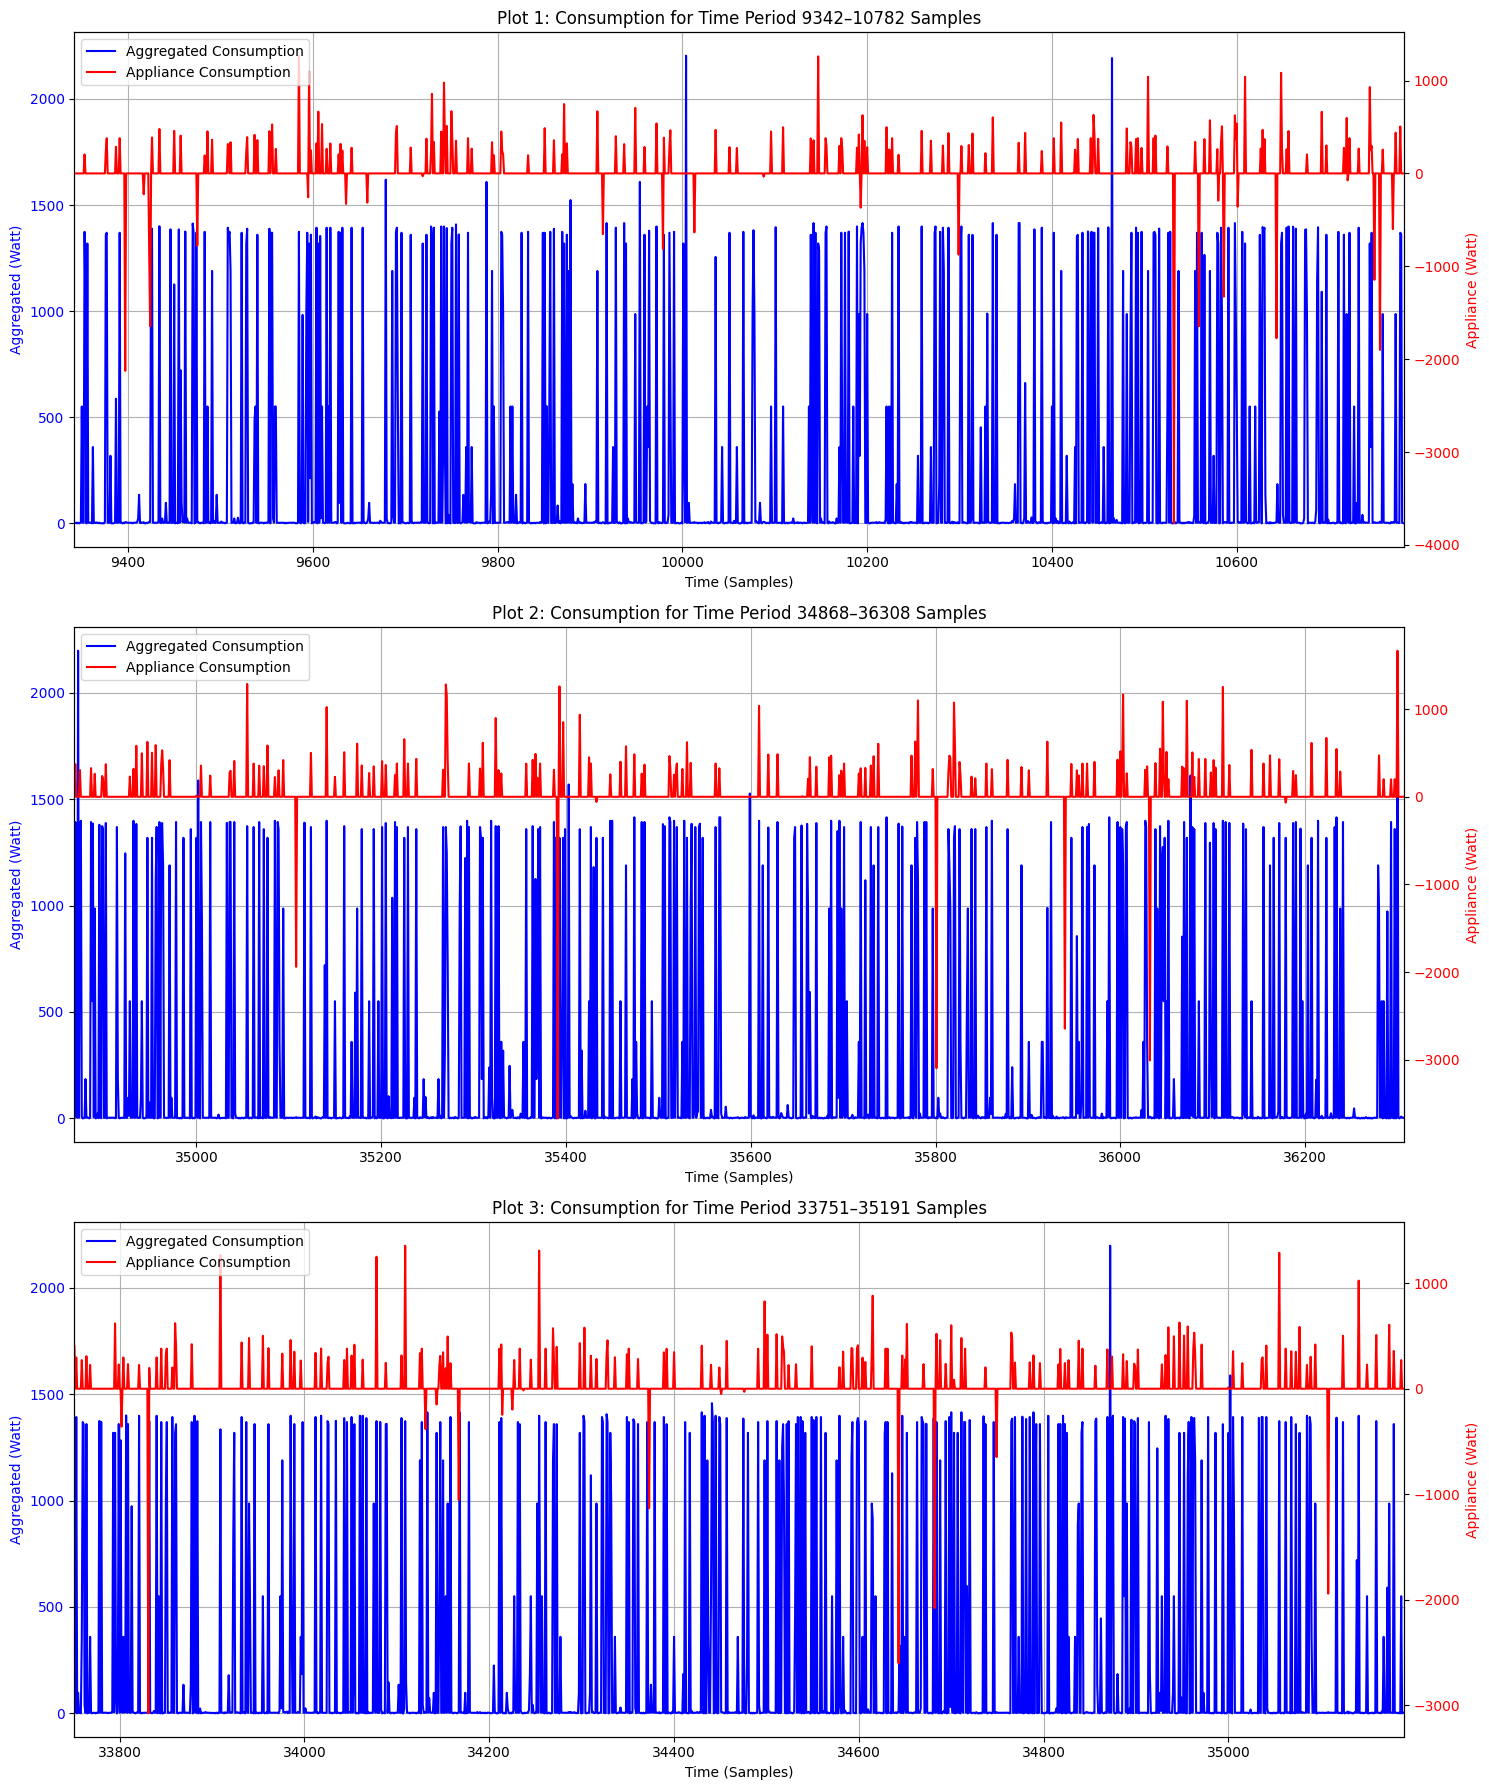

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Normalize raw data
# Ensure max values are scalars
max_agg_val = float(max_agg)
max_app_val = float(max_app)

# Normalize input aggregated and output appliance using their max values
X_scaled = X_raw / max_agg_val
y_scaled = y_raw / max_app_val

# Step 2: Train / Test Split
num_samples = X_scaled.shape[0]
train_ratio = 0.8
train_split_index = int(num_samples * train_ratio)

train_indices = np.arange(0, train_split_index)
test_indices  = np.arange(train_split_index, num_samples)

print(f"Dataset size:     {num_samples} samples")
print(f"Train set size:   {len(train_indices)} samples ({train_ratio*100:.0f}%)")
print(f"Test set size:    {len(test_indices)} samples ({(1-train_ratio)*100:.0f}%)")

# Step 3: Build 3-D tensors for Keras
timesteps = X_scaled.shape[1]

X_train = X_scaled[train_indices].reshape(-1, timesteps, 1)
X_test  = X_scaled[test_indices].reshape(-1, timesteps, 1)
y_train = y_scaled[train_indices].reshape(-1, timesteps, 1)
y_test  = y_scaled[test_indices].reshape(-1, timesteps, 1)

print(f"X_train shape: {X_train.shape}  |  y_train shape: {y_train.shape}")
print(f"X_test  shape: {X_test.shape}   |  y_test  shape: {y_test.shape}")

# Step 4: Denormalised signals for plotting
if len(X_raw.shape) > 1:
    aggregated_signal = X_raw[:, 0] * max_agg_val
    appliance_signal  = y_raw[:, 0] * max_app_val
else:
    aggregated_signal = X_raw * max_agg_val
    appliance_signal  = y_raw * max_app_val

data_length = len(aggregated_signal)

# Step 5: 3 Random time-series plots
period_length_samples       = 24 * 60
num_plots                   = 3
appliance_activity_threshold = 0.1

active_appliance_indices = np.where(appliance_signal > appliance_activity_threshold)[0]

plot_start_indices = []

# Generate num_plots - 1 fully random start indices
for _ in range(num_plots - 1):
    start_idx = np.random.randint(0, max(1, data_length - period_length_samples))
    plot_start_indices.append(start_idx)

# Last plot: try to guarantee appliance is active in that window
if len(active_appliance_indices) > 0:
    valid_active_starts = active_appliance_indices[
        active_appliance_indices < data_length - period_length_samples
    ]
    if len(valid_active_starts) > 0:
        plot_start_indices.append(np.random.choice(valid_active_starts))
    else:
        print("Warning: no appliance-active segment long enough; using random window.")
        plot_start_indices.append(
            np.random.randint(0, max(1, data_length - period_length_samples))
        )
else:
    print("Warning: no appliance activity detected; all plots are random.")
    plot_start_indices.append(
        np.random.randint(0, max(1, data_length - period_length_samples))
    )

# Safety top-up in case of edge cases
while len(plot_start_indices) < num_plots:
    plot_start_indices.append(
        np.random.randint(0, max(1, data_length - period_length_samples))
    )

# Plot each window with dual y-axes
plt.figure(figsize=(15, 6 * num_plots))

for i, start_idx in enumerate(plot_start_indices):
    end_idx    = start_idx + period_length_samples
    time_points = np.arange(start_idx, end_idx)

    current_agg_data = aggregated_signal[start_idx:end_idx]
    current_app_data = appliance_signal[start_idx:end_idx]

    ax1 = plt.subplot(num_plots, 1, i + 1)

    # Primary y-axis: aggregated consumption
    ax1.plot(time_points, current_agg_data, color='blue', label='Aggregated Consumption')
    ax1.set_xlabel('Time (Samples)')
    ax1.set_ylabel('Aggregated (Watt)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_xlim(time_points.min(), time_points.max())

    # Secondary y-axis: appliance consumption
    ax2 = ax1.twinx()
    ax2.plot(time_points, current_app_data, color='red', label='Appliance Consumption')
    ax2.set_ylabel('Appliance (Watt)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    ax1.set_title(f'Plot {i+1}: Consumption for Time Period {start_idx}–{end_idx} Samples')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    ax1.grid(True)

plt.tight_layout()
plt.show()


Original training set size: 40000 samples
New training set size: 32000 samples (80% of original train)
Validation set size: 8000 samples (20% of original train)
Test set size: 10000 samples (remains unchanged)

--- Training Simple RNN Model ---
Simple RNN Test MSE: 0.0000
Simple RNN Training Loss: 0.0000
Simple RNN Validation Loss: 0.0000

--- Training LSTM Model ---
LSTM Test MSE: 0.0000
LSTM Training Loss: 0.0000
LSTM Validation Loss: 0.0000

--- Training GRU Model ---
GRU Test MSE: 0.0000
GRU Training Loss: 0.0000
GRU Validation Loss: 0.0000

--- Model Training and Evaluation Complete ---
RNN Test MSE: 0.0000
LSTM Test MSE: 0.0000
GRU Test MSE: 0.0000


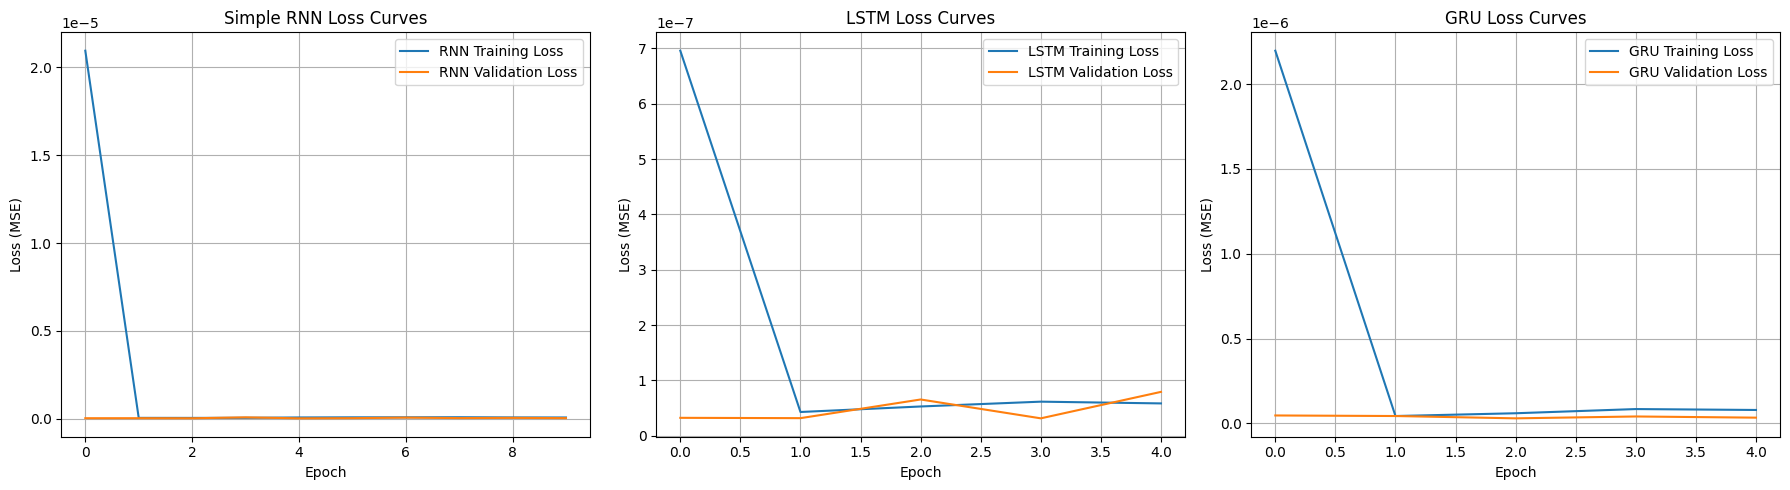

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import warnings

# Suppress specific Keras UserWarnings about input_shape
warnings.filterwarnings('ignore', category=UserWarning, module='keras.src.layers.rnn.rnn')

# Define timesteps and output_dim from the training data shape
timesteps = X_train.shape[1]
output_dim = y_train.shape[-1]

# Increased epochs and patience to avoid premature stopping
epochs_count = 150

# Create an independent validation set
train_val_split_ratio = 0.8
num_samples_original_train = X_train.shape[0]
new_train_split_index = int(num_samples_original_train * train_val_split_ratio)

X_train_new = X_train[:new_train_split_index]
y_train_new = y_train[:new_train_split_index]
X_val = X_train[new_train_split_index:]
y_val = y_train[new_train_split_index:]

print(f"Original training set size: {num_samples_original_train} samples")
print(f"New training set size: {X_train_new.shape[0]} samples ({train_val_split_ratio*100:.0f}% of original train)")
print(f"Validation set size: {X_val.shape[0]} samples ({(1-train_val_split_ratio)*100:.0f}% of original train)")
print(f"Test set size: {X_test.shape[0]} samples (remains unchanged)")

# patience=5 as required by assignment
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 1. Define and train the Simple RNN model
print("\n--- Training Simple RNN Model ---")
rnn_model = Sequential([
    SimpleRNN(128, activation='tanh', input_shape=(timesteps, 1), return_sequences=True),
    Dropout(0.2),
    SimpleRNN(64, activation='tanh', return_sequences=True),
    Dense(1)
])
rnn_model.compile(optimizer='adam', loss='mse')
rnn_history = rnn_model.fit(X_train_new, y_train_new, epochs=epochs_count, batch_size=32, verbose=0,
                             validation_data=(X_val, y_val), callbacks=[early_stopping_callback])

rnn_loss = rnn_model.evaluate(X_test, y_test, verbose=0)
print(f"Simple RNN Test MSE: {rnn_loss:.4f}")
print(f"Simple RNN Training Loss: {rnn_history.history['loss'][-1]:.4f}")
print(f"Simple RNN Validation Loss: {rnn_history.history['val_loss'][-1]:.4f}")

# 2. Define and train the LSTM model
print("\n--- Training LSTM Model ---")
lstm_model = Sequential([
    LSTM(128, input_shape=(timesteps, 1), return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_history = lstm_model.fit(X_train_new, y_train_new, epochs=epochs_count, batch_size=32, verbose=0,
                               validation_data=(X_val, y_val), callbacks=[early_stopping_callback])

lstm_loss = lstm_model.evaluate(X_test, y_test, verbose=0)
print(f"LSTM Test MSE: {lstm_loss:.4f}")
print(f"LSTM Training Loss: {lstm_history.history['loss'][-1]:.4f}")
print(f"LSTM Validation Loss: {lstm_history.history['val_loss'][-1]:.4f}")

# 3. Define and train the GRU model
print("\n--- Training GRU Model ---")
gru_model = Sequential([
    GRU(128, input_shape=(timesteps, 1), return_sequences=True),
    Dropout(0.2),
    GRU(64, return_sequences=True),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse')
gru_history = gru_model.fit(X_train_new, y_train_new, epochs=epochs_count, batch_size=32, verbose=0,
                             validation_data=(X_val, y_val), callbacks=[early_stopping_callback])

gru_loss = gru_model.evaluate(X_test, y_test, verbose=0)
print(f"GRU Test MSE: {gru_loss:.4f}")
print(f"GRU Training Loss: {gru_history.history['loss'][-1]:.4f}")
print(f"GRU Validation Loss: {gru_history.history['val_loss'][-1]:.4f}")

print("\n--- Model Training and Evaluation Complete ---")
print(f"RNN Test MSE: {rnn_loss:.4f}")
print(f"LSTM Test MSE: {lstm_loss:.4f}")
print(f"GRU Test MSE: {gru_loss:.4f}")

# Plotting Loss Curves
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(rnn_history.history['loss'], label='RNN Training Loss')
plt.plot(rnn_history.history['val_loss'], label='RNN Validation Loss')
plt.title('Simple RNN Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(lstm_history.history['loss'], label='LSTM Training Loss')
plt.plot(lstm_history.history['val_loss'], label='LSTM Validation Loss')
plt.title('LSTM Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(gru_history.history['loss'], label='GRU Training Loss')
plt.plot(gru_history.history['val_loss'], label='GRU Validation Loss')
plt.title('GRU Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

---- Regression Metrics on Denormalized Data ----

### Simple RNN ###
RNN Train RMSE: 0.1839
RNN Train MAE: 0.0715
RNN Train Max Error: 3.9815
RNN Test RMSE: 0.1788
RNN Test MAE: 0.0706
RNN Test Max Error: 3.5467

### LSTM ###
LSTM Train RMSE: 0.2025
LSTM Train MAE: 0.0588
LSTM Train Max Error: 3.9971
LSTM Test RMSE: 0.1965
LSTM Test MAE: 0.0573
LSTM Test Max Error: 3.5610

### GRU ###
GRU Train RMSE: 0.2394
GRU Train MAE: 0.1532
GRU Train Max Error: 3.9248
GRU Test RMSE: 0.2336
GRU Test MAE: 0.1518
GRU Test Max Error: 3.4568

---- Plotting Per-Sample Errors for Test Set ----


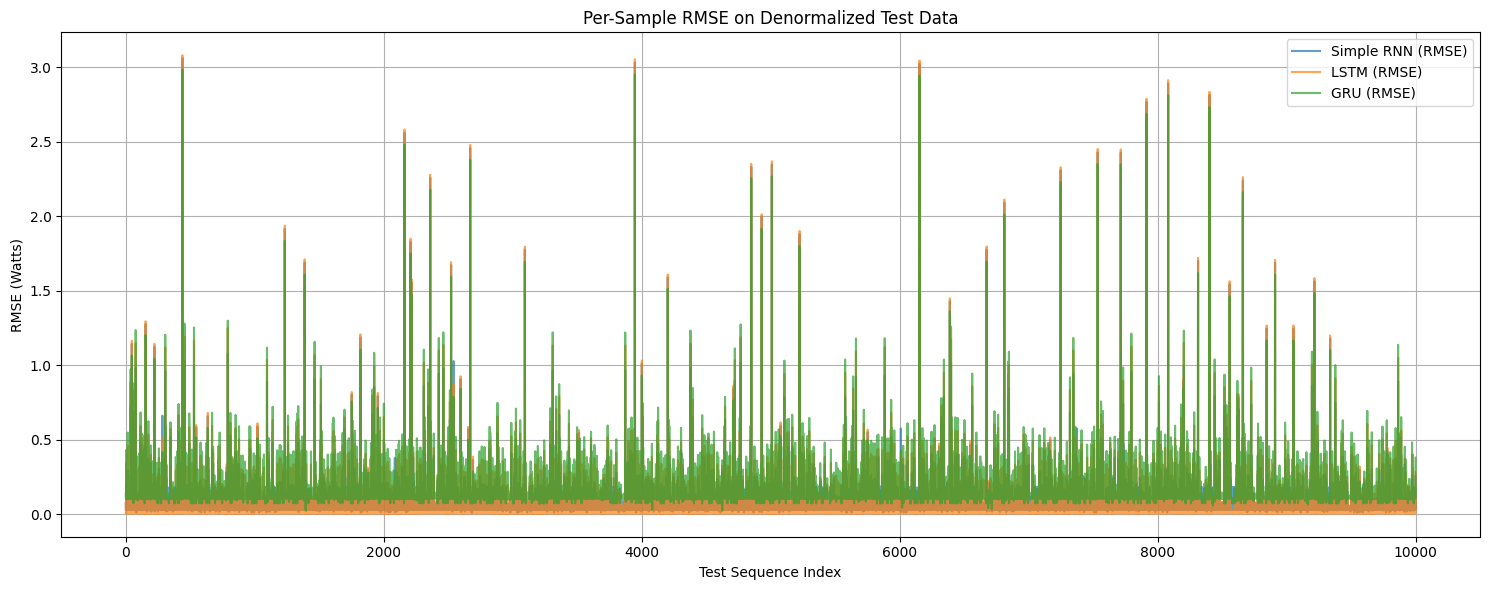

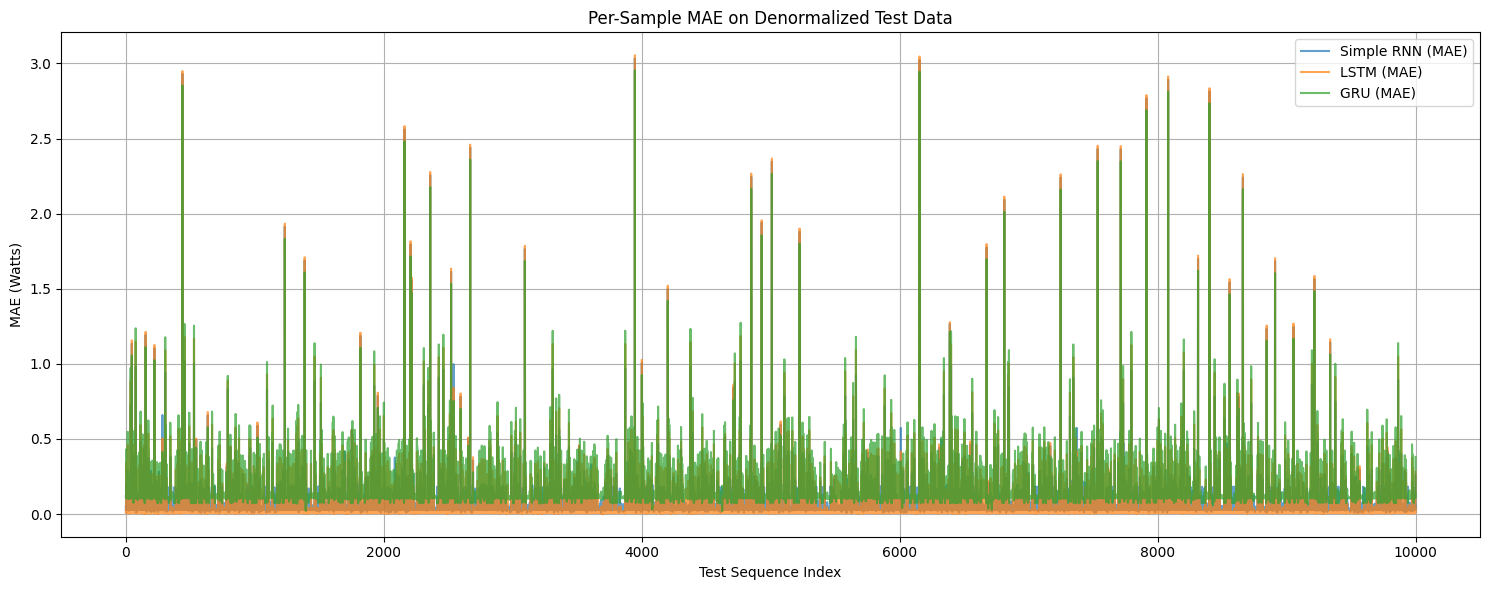

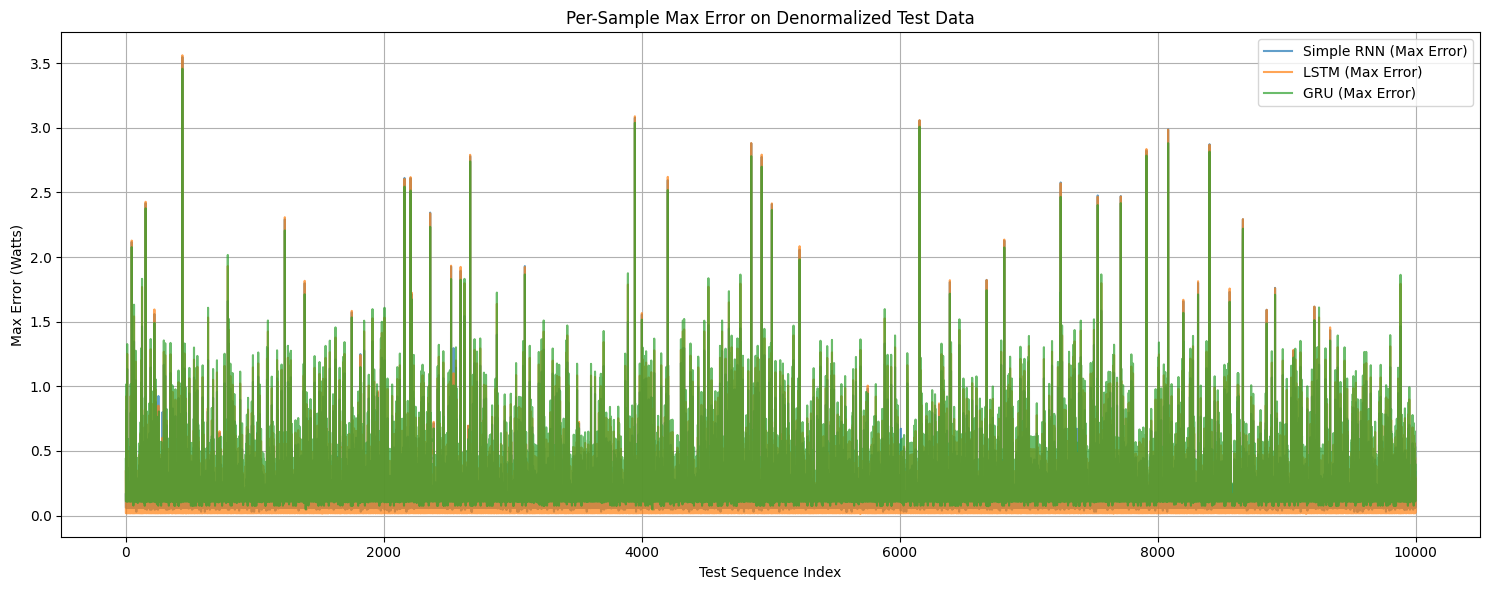

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Helper function to denormalize predictions and true values
def denormalize_data(scaled_data, max_value):
    if isinstance(max_value, np.ndarray) and max_value.size == 1:
        max_value = max_value.item()
    return scaled_data * max_value

# Helper function to calculate regression metrics
def calculate_overall_metrics(y_true_denorm_full_sequence, y_pred_denorm, prefix=""):
    # Flatten arrays to compute metrics across ALL 40 timesteps for ALL sequences
    y_true_flat = y_true_denorm_full_sequence.flatten()
    y_pred_flat = y_pred_denorm.flatten()

    rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    max_err = np.max(np.abs(y_true_flat - y_pred_flat))

    print(f"{prefix} RMSE: {rmse:.4f}")
    print(f"{prefix} MAE: {mae:.4f}")
    print(f"{prefix} Max Error: {max_err:.4f}")
    return rmse, mae, max_err

def calculate_per_sequence_metrics(y_true_denorm, y_pred_denorm):
    # Remove the unnecessary 3rd dimension if it exists
    y_true = np.squeeze(y_true_denorm)
    y_pred = np.squeeze(y_pred_denorm)

    # Calculate metrics PER sequence
    rmse_per_seq = np.sqrt(np.mean((y_true - y_pred)**2, axis=1))
    mae_per_seq = np.mean(np.abs(y_true - y_pred), axis=1)
    max_err_per_seq = np.max(np.abs(y_true - y_pred), axis=1)

    return rmse_per_seq, mae_per_seq, max_err_per_seq

# Denormalization factor
denorm_factor = max_app.item()

print("---- Regression Metrics on Denormalized Data ----")

# Predict on training and test sets for all models
y_pred_rnn_train_scaled = rnn_model.predict(X_train_new, verbose=0)
y_pred_rnn_train_denorm = denormalize_data(y_pred_rnn_train_scaled, denorm_factor)
y_train_new_denorm = denormalize_data(y_train_new, denorm_factor)

y_pred_rnn_test_scaled = rnn_model.predict(X_test, verbose=0)
y_pred_rnn_test_denorm = denormalize_data(y_pred_rnn_test_scaled, denorm_factor)
y_test_denorm = denormalize_data(y_test, denorm_factor)

y_pred_lstm_train_scaled = lstm_model.predict(X_train_new, verbose=0)
y_pred_lstm_train_denorm = denormalize_data(y_pred_lstm_train_scaled, denorm_factor)

y_pred_lstm_test_scaled = lstm_model.predict(X_test, verbose=0)
y_pred_lstm_test_denorm = denormalize_data(y_pred_lstm_test_scaled, denorm_factor)

y_pred_gru_train_scaled = gru_model.predict(X_train_new, verbose=0)
y_pred_gru_train_denorm = denormalize_data(y_pred_gru_train_scaled, denorm_factor)

y_pred_gru_test_scaled = gru_model.predict(X_test, verbose=0)
y_pred_gru_test_denorm = denormalize_data(y_pred_gru_test_scaled, denorm_factor)

# Calculate sequence-wise metrics for the Test Set
rnn_rmse, rnn_mae, rnn_max = calculate_per_sequence_metrics(y_test_denorm, y_pred_rnn_test_denorm)
lstm_rmse, lstm_mae, lstm_max = calculate_per_sequence_metrics(y_test_denorm, y_pred_lstm_test_denorm)
gru_rmse, gru_mae, gru_max = calculate_per_sequence_metrics(y_test_denorm, y_pred_gru_test_denorm)

# Simple RNN Model
print("\n### Simple RNN ###")
calculate_overall_metrics(y_train_new_denorm, y_pred_rnn_train_denorm, "RNN Train")
calculate_overall_metrics(y_test_denorm, y_pred_rnn_test_denorm, "RNN Test")

# LSTM Model
print("\n### LSTM ###")
calculate_overall_metrics(y_train_new_denorm, y_pred_lstm_train_denorm, "LSTM Train")
calculate_overall_metrics(y_test_denorm, y_pred_lstm_test_denorm, "LSTM Test")

# GRU Model
print("\n### GRU ###")
calculate_overall_metrics(y_train_new_denorm, y_pred_gru_train_denorm, "GRU Train")
calculate_overall_metrics(y_test_denorm, y_pred_gru_test_denorm, "GRU Test")

print("\n---- Plotting Per-Sample Errors for Test Set ----")

test_sequence_indices = np.arange(len(y_test_denorm))

# Plot for Per-Sample RMSE
plt.figure(figsize=(15, 6))
plt.plot(test_sequence_indices, rnn_rmse, label='Simple RNN (RMSE)', alpha=0.7)
plt.plot(test_sequence_indices, lstm_rmse, label='LSTM (RMSE)', alpha=0.7)
plt.plot(test_sequence_indices, gru_rmse, label='GRU (RMSE)', alpha=0.7)
plt.title('Per-Sample RMSE on Denormalized Test Data')
plt.xlabel('Test Sequence Index')
plt.ylabel('RMSE (Watts)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot for Per-Sample MAE
plt.figure(figsize=(15, 6))
plt.plot(test_sequence_indices, rnn_mae, label='Simple RNN (MAE)', alpha=0.7)
plt.plot(test_sequence_indices, lstm_mae, label='LSTM (MAE)', alpha=0.7)
plt.plot(test_sequence_indices, gru_mae, label='GRU (MAE)', alpha=0.7)
plt.title('Per-Sample MAE on Denormalized Test Data')
plt.xlabel('Test Sequence Index')
plt.ylabel('MAE (Watts)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot for Per-Sample Max Error
plt.figure(figsize=(15, 6))
plt.plot(test_sequence_indices, rnn_max, label='Simple RNN (Max Error)', alpha=0.7)
plt.plot(test_sequence_indices, lstm_max, label='LSTM (Max Error)', alpha=0.7)
plt.plot(test_sequence_indices, gru_max, label='GRU (Max Error)', alpha=0.7)
plt.title('Per-Sample Max Error on Denormalized Test Data')
plt.xlabel('Test Sequence Index')
plt.ylabel('Max Error (Watts)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

--- Generating Waveform Plots: 2 Active Sequences, 2 Inactive Sequences ---
Active threshold (75th percentile): 0.31 W


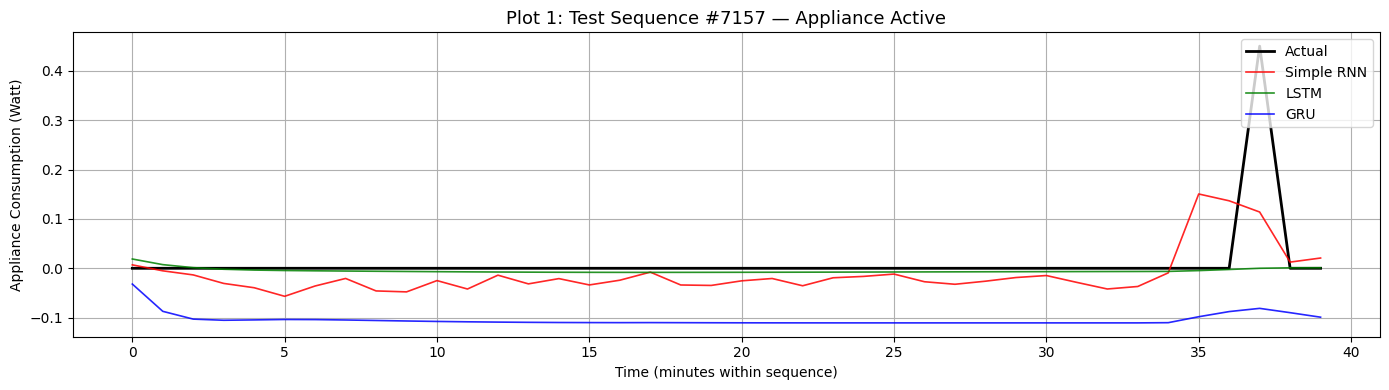

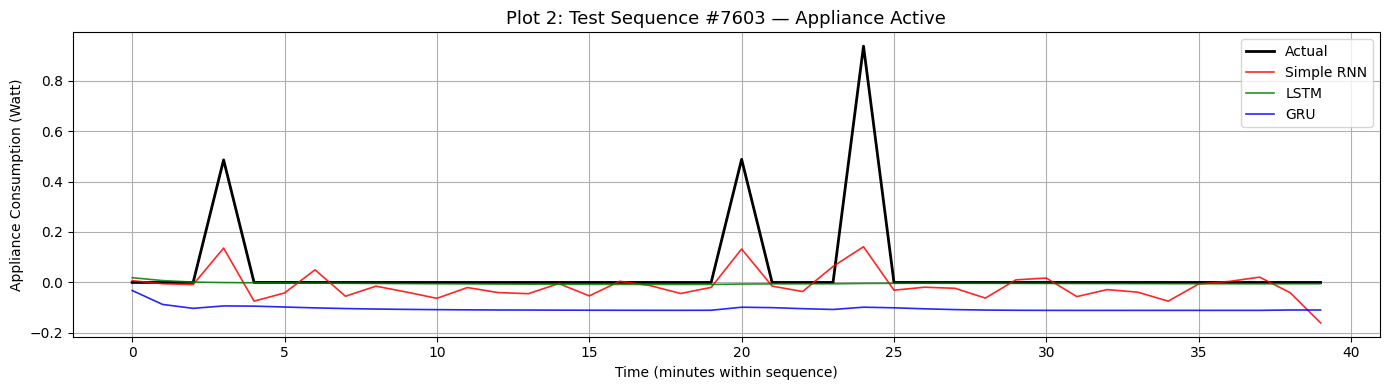

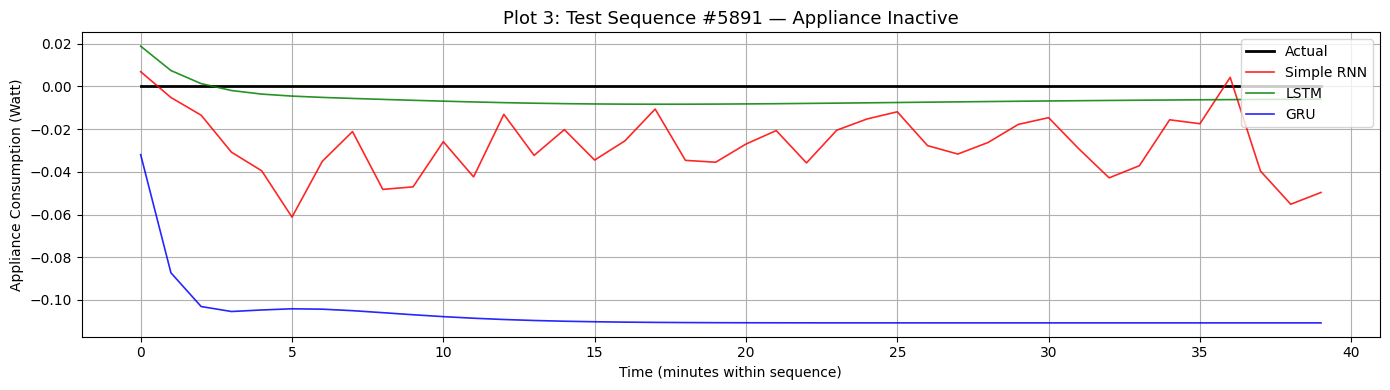

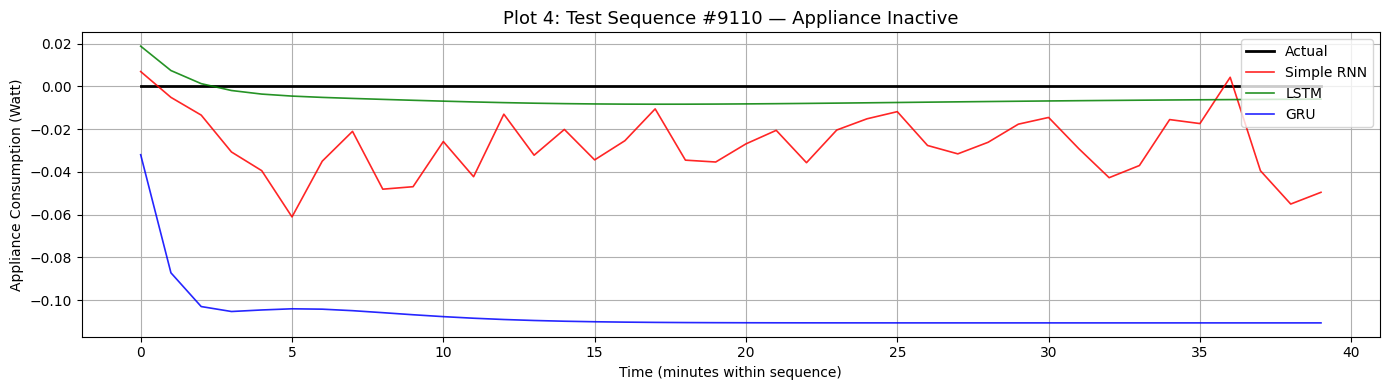

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import random

print("--- Generating Waveform Plots: 2 Active Sequences, 2 Inactive Sequences ---")

# Squeeze predictions and ground truth
y_test_sq          = np.squeeze(y_test_denorm)
y_pred_rnn_sq      = np.squeeze(y_pred_rnn_test_denorm)
y_pred_lstm_sq     = np.squeeze(y_pred_lstm_test_denorm)
y_pred_gru_sq      = np.squeeze(y_pred_gru_test_denorm)

# Adaptive threshold
# Guarantees ~25% active and ~75% inactive regardless of dataset scale
max_per_seq = np.array([np.max(y_test_sq[i]) for i in range(len(y_test_sq))])
active_threshold_watts = np.percentile(max_per_seq, 75)
print(f"Active threshold (75th percentile): {active_threshold_watts:.2f} W")

active_indices   = [i for i in range(len(y_test_sq)) if np.max(y_test_sq[i]) > active_threshold_watts]
inactive_indices = [i for i in range(len(y_test_sq)) if np.max(y_test_sq[i]) <= active_threshold_watts]

if len(active_indices) < 2 or len(inactive_indices) < 2:
    print("Warning: not enough active/inactive sequences; using whatever is available.")
    active_indices   = active_indices   or inactive_indices[:2]
    inactive_indices = inactive_indices or active_indices[:2]

selected_active   = random.sample(active_indices,   min(2, len(active_indices)))
selected_inactive = random.sample(inactive_indices, min(2, len(inactive_indices)))

# Order: active first, then inactive
selected_indices = selected_active + selected_inactive
labels           = ["Active", "Active", "Inactive", "Inactive"]

timestep_axis = np.arange(y_test_sq.shape[1])  # x-axis: 0 … m-1 minutes

# 4 separate figures
for plot_num, (idx, status) in enumerate(zip(selected_indices, labels), start=1):
    fig, ax = plt.subplots(figsize=(14, 4))

    ax.plot(timestep_axis, y_test_sq[idx],      color='black', linewidth=2,   label='Actual')
    ax.plot(timestep_axis, y_pred_rnn_sq[idx],  color='red',   linewidth=1.2, label='Simple RNN', alpha=0.85)
    ax.plot(timestep_axis, y_pred_lstm_sq[idx], color='green', linewidth=1.2, label='LSTM',       alpha=0.85)
    ax.plot(timestep_axis, y_pred_gru_sq[idx],  color='blue',  linewidth=1.2, label='GRU',        alpha=0.85)

    ax.set_title(f'Plot {plot_num}: Test Sequence #{idx} — Appliance {status}', fontsize=13)
    ax.set_xlabel('Time (minutes within sequence)')
    ax.set_ylabel('Appliance Consumption (Watt)')
    ax.legend(loc='upper right')
    ax.grid(True)
    plt.tight_layout()
    plt.show()